In [ ]:
# Patlak plot

In [ ]:
# Patlak plot for 1TCM

In [16]:
time_points=time=[0,30,75,150,135,165,195,225,
  270,450,750,1050,1500,2100,2700]
TAC_input=aorta=[0,17423,10192,8354,8087,7793,7276,6929,
  6664,5718,4809,4254,3720,3212,2827]
TAC=brain=[0,1698,3269,3467,3687,3896,4116,4283,
  4520,5322,6440,7419,8770,10420,11795]

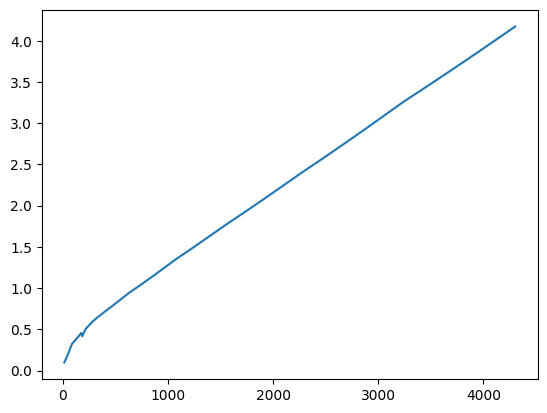

In [2]:
import numpy as np # numerical functions
# Interpolate TACs to have samples every 1 s
from scipy import interpolate # Import function interpolate from scipy
interpolated_time_points=np.arange(0,2701,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_input)
TAC_input_interpolated=f(interpolated_time_points)

# Define function for cumulative integral
def cumulative_function(tac):
    res=np.ones(len(tac))
    res[0]=tac[0]
    for k in np.arange(1,len(res),1): 
        res[k]=tac[k]+res[k-1]
    return res

# Make Patlak plot
import matplotlib.pyplot as plt # import matplotlib for plotting
first_time_point=1
plt.plot(cumulative_function(TAC_input_interpolated)[
    time_points[first_time_point]:]/
    TAC_input_interpolated[time_points[first_time_point]:],
    np.array(TAC_interpolated[time_points[first_time_point]:])/
    TAC_input_interpolated[time_points[first_time_point]:])

In [7]:
first_time_point=8
x=np.array(cumulative_function(TAC_input_interpolated)[
    time_points[first_time_point]:]/TAC_input_interpolated[time_points[first_time_point]:])
y=np.array(TAC_interpolated[time_points[
    first_time_point]:])/TAC_input_interpolated[time_points[first_time_point]:]
z=np.polyfit(x,y,1)

In [13]:
# Import packages
import numpy as np

# tac=time activity curve; first time point is expected to be 0
# time=mid point of time frames; first time point is expected to be 0
# end=frame number of the last frame to be included; between 1 and len(tac)
def Riemann_integral(tac,time,end):
    if len(tac)!=len(time):
        print("ERROR (Riemann_integral): input vectors have different lengths")
    # Define frame durations
    frames=np.zeros(len(tac)) # Initialise frames
    frames[0]=2*(time[1]-time[0]) # Find first value
    for k in range(1,len(tac)-2): # Find next values until the second to last
        frames[k]=2*(time[k+1]-time[k]-frames[k-1]/2)
    frames[len(tac)-2]=2*(time[len(tac)-1]-time[len(tac)-2]-frames[len(tac)-3]/2) # Find last value
    frames=frames[:(len(frames)-1)]
    # Find integral
    res=np.zeros(len(tac)) # Initialise integral
    for k in range(1,end+1):
        res[k]=tac[k]*frames[k-1]+res[k-1] # Add value of next frame
    res[k]=res[k]-tac[k]*frames[k-1]/2 # Last frame is corrected
    return round(res[k])

Riemann_integral(TAC_input,time_points,14)

12366180

In [ ]:
# Patlak plot for 2TCM

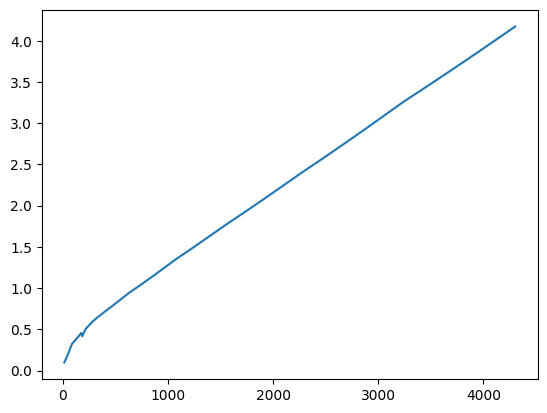

In [17]:
# Interpolate TACs to contain 1-second interval
interpolated_time_points=np.arange(0,2701,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_input)
TAC_input_interpolated=f(interpolated_time_points)

# Patlak plot
first_time_point=1
plt.plot(cumulative_function(TAC_input_interpolated)[
    time_points[first_time_point]:]/
    TAC_input_interpolated[time_points[first_time_point]:],
    TAC_interpolated[time_points[first_time_point]:]/
    TAC_input_interpolated[time_points[first_time_point]:])

In [34]:
first_time_point=3
last_time_point=12
print(time_points[first_time_point])
x=cumulative_function(TAC_input_interpolated[
  time_points[first_time_point]:time_points[last_time_point]]/
  TAC_input_interpolated[time_points[first_time_point]:
  time_points[last_time_point]])
y=np.array(TAC_interpolated)[time_points[first_time_point]:
  time_points[last_time_point]]/np.array(TAC_input_interpolated)[
  time_points[first_time_point]:time_points[last_time_point]]
z=np.polyfit(x,y,1)

150


In [ ]:
# Patlak plot for 2TCM without blood input

In [36]:
time_points=time=[0,45,135,225,315,420,540,750,1050,
  1350,1650,1950,2250,2550,2850,3150,3450]
TAC=putamen=[0,736,1954,2342,2696,2931,2993,3732,4278,
  4340,4564,4813,4853,4814,5017,4816,4843]
TAC_ref=cerebellum=[0,898,2177,2468,2686,2749,2802,2977,3110,
  3027,2853,2907,2711,2790,2627,2450,2210]

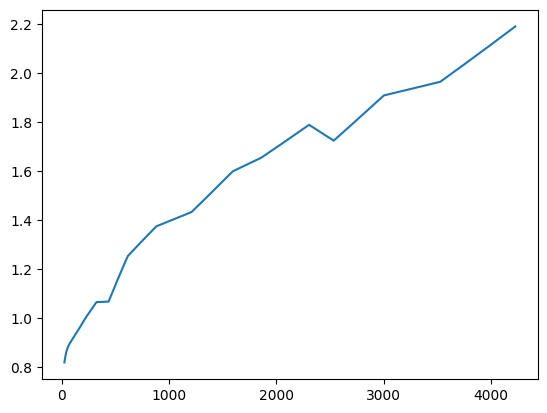

In [37]:
# Interpolate TACs to contain 1-second interval
interpolated_time_points=np.arange(0,3451,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_ref)
TAC_ref_interpolated=f(interpolated_time_points)

# Make Patlak plot
first_time_point=1
plt.plot(cumulative_function(TAC_ref_interpolated)[
  time_points[first_time_point]:]/
  TAC_ref_interpolated[time_points[first_time_point]:],
  TAC_interpolated[time_points[first_time_point]:]/
  TAC_ref_interpolated[time_points[first_time_point]:])

In [ ]:
# Logan plot

In [ ]:
# Logan plot for 1TCM

In [38]:
time_points=time=[0,30,90,105,270,450,
  630,810,1080,1440,1800,2160,
  2520,2880,3240,3600,3960]
TAC_input=blood=[0,33.831,23.569,11.986,6.984,3.493,
  2.623,2.286,2.014,1.788,1.584,1.448,
  1.325,1.230,1.142,1.053,0.995]
TAC=thalamus=[0,3.956,9.870,11.543,12.561,13.175,
  13.127,12.891,12.388,11.713,11.076,10.493,
  9.765,9.208,8.604,8.170,7.721]

In [39]:
interpolated_time_points=np.arange(0,3961,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_input)
TAC_input_interpolated=f(interpolated_time_points)

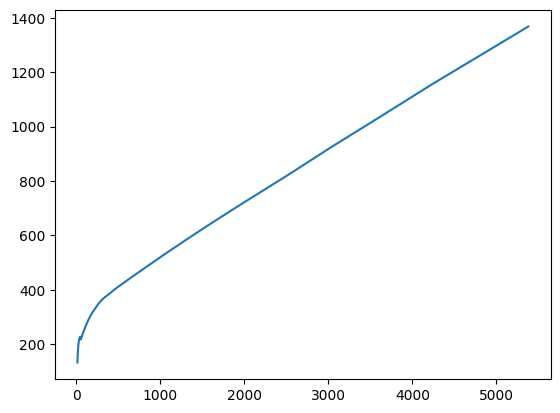

In [40]:
first_time_point=1
plt.plot(cumulative_function(TAC_interpolated)[time_points[
  first_time_point]:]/TAC_interpolated[time_points[first_time_point]:],
  cumulative_function(TAC_input_interpolated)[time_points[
  first_time_point]:]/TAC_interpolated[time_points[first_time_point]:])

In [53]:
# Fit line
first_time_point=7
x=np.array((cumulative_function(TAC_input_interpolated[
    interpolated_time_points[first_time_point]:])/
            TAC_interpolated[interpolated_time_points[first_time_point]:]))
y=np.array((cumulative_function(TAC_interpolated[
    interpolated_time_points[first_time_point]:])/
            TAC_interpolated[interpolated_time_points[first_time_point]:]))
z=np.polyfit(x,y,1)

In [ ]:
# Logan plot for 2TCM

In [54]:
time=[0,30,90,150,300,450,600,
  800,1000,1300,1600,2000,2400,2800]
TAC_input=[0,33.831,23.569,11.986,6.984,3.493,2.623,
  2.286,2.014,1.788,1.584,1.448,1.325,1.230]
TAC=[0,5.43,13.17,16.64,18.12,18.25,18.23,
  18.01,17.13,16.76,15.21,14.49,13.83,12.93]

In [ ]:
# Logan plot for 2TCM without blood input

In [55]:
time_points=time=[0,30,90,150,270,450,
  630,810,1080,1440,1800,2160,
  2520,2880,3240,3600,3960]
TAC=thalamus=[0,3.956,9.870,11.543,12.561,13.175,
  13.127,12.891,12.388,11.713,11.076,10.493,
  9.765,9.208,8.604,8.170,7.721]
TAC_ref=occipital_cortex=[0,3.812,9.156,10.007,9.495,8.094,
  6.789,5.764,4.786,3.929,3.388,3.034,
  2.771,2.551,2.377,2.232,2.136]

In [56]:
from scipy import interpolate
interpolated_time_points=np.arange(0,3961,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_ref)
TAC_ref_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_ref)
TAC_ref_interpolated=f(interpolated_time_points)

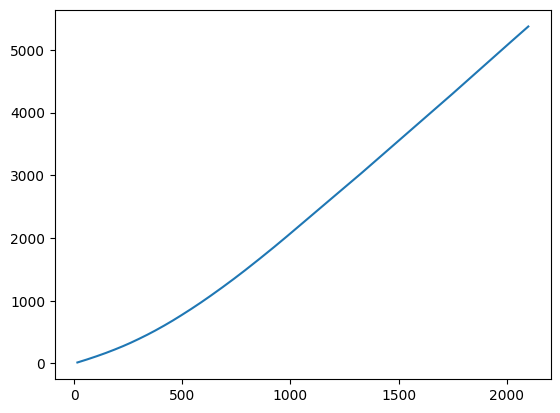

In [57]:
first_time_point=1
plt.plot(cumulative_function(TAC_ref_interpolated)[time_points[
  first_time_point]:]/TAC_interpolated[time_points[first_time_point]:],
  cumulative_function(TAC_interpolated)[time_points[
  first_time_point]:]/TAC_interpolated[time_points[first_time_point]:])

In [69]:
first_time_point=8
x=cumulative_function(TAC_ref_interpolated)[time_points[
  first_time_point]:]/TAC_interpolated[time_points[first_time_point]:]
y=cumulative_function(TAC_interpolated)[time_points[first_time_point]:]/TAC_interpolated[time_points[first_time_point]:]
z=np.polyfit(x,y,1)

In [ ]:
# Alternative Logan plot

30


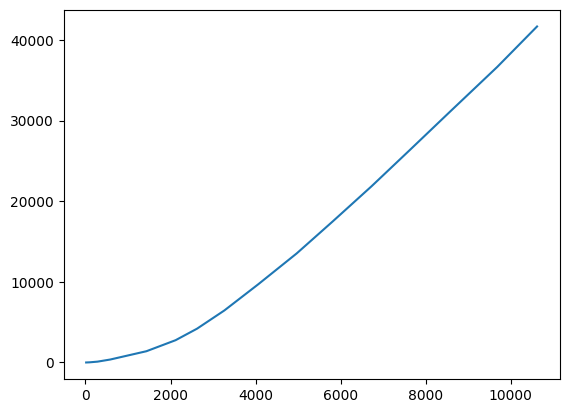

In [90]:
first_time_point=1
print(time_points[first_time_point])
plt.plot(cumulative_function(TAC_input_interpolated)[
  time_points[first_time_point:]]/
  TAC_input_interpolated[time_points[first_time_point:]],
  cumulative_function(TAC_interpolated)[time_points[first_time_point:]]/
  TAC_input_interpolated[time_points[first_time_point:]])

810


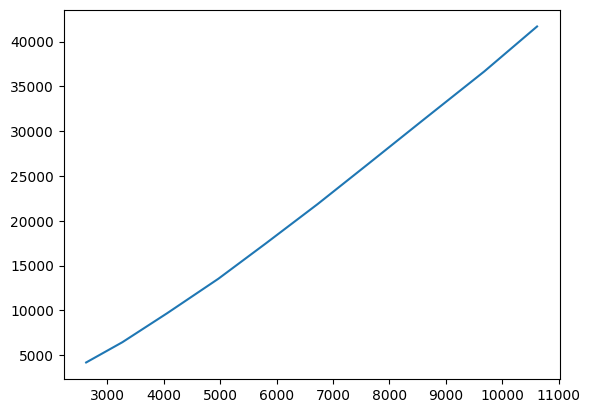

In [91]:
first_time_point=7
print(time_points[first_time_point])
plt.plot(cumulative_function(TAC_input_interpolated)[
  time_points[first_time_point:]]/
  TAC_input_interpolated[time_points[first_time_point:]],
  cumulative_function(TAC_interpolated)[time_points[first_time_point:]]/
  TAC_input_interpolated[time_points[first_time_point:]])

In [ ]:
# Defining the dynamic equilibrium

In [92]:
time_points=time=[0,3,8,13,18,23,28,33,38,
  43,48,53,58,63,68,75,85,
  95,110,130,150,175,205,235,265]
TAC_input=aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
  42104,34094,27709,23290,22109,21168,18760,16693,
  15754,14843,14245,13780,13292,12567,12291,11974]
TAC=pancreas=[0,43,80,188,886,6350,9795,13184,16079,
  16296,20631,18088,15458,18361,23530,16859,16674,
  16933,14687,13925,12664,12138,11410,10810,10611]

/var/folders/_c/_gkz3gx12qqdv0jj7jh96zqc0000gn/T/ipykernel_32377/3189947508.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(time_points,np.array(TAC_input)/np.array(TAC))


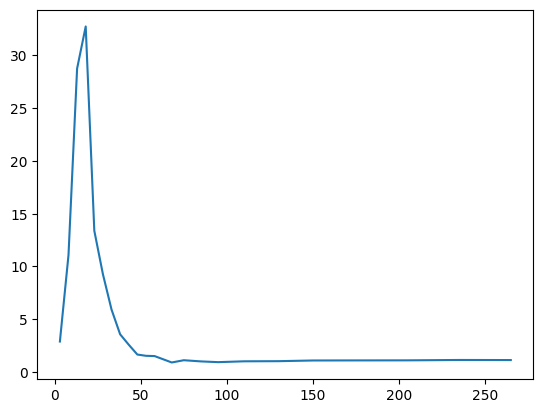

In [93]:
plt.plot(time_points,np.array(TAC_input)/np.array(TAC))